# 04. Požymių abliacija: akcelerometras, giroskopas, visi požymiai

Šiame etape **nedarome** naujo hiperparametrų derinimo, naujo TRAIN/TEST skaidymo, robustness bandymų ir SOM.

Tikslas — tuo pačiu subject-disjoint skaidymu patikrinti, kaip k-NN, SVM ir MLP Macro-F1 keičiasi, kai naudojami:

1. tik akcelerometro požymiai;
2. tik giroskopo požymiai;
3. visi 561 požymiai.

Hiperparametrai paliekami tokie, kokie buvo parinkti 2 ir 3 etapų TRAIN cross-validation: k-NN `n_neighbors=11`, `weights=distance`; SVM `C=0.01`; MLP `hidden_layer_sizes=(100,)`, `alpha=0.001`, `random_state=42`, `max_iter=500`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_STATE = 42


## TRAIN/TEST užkrovimas

Naudojamas tik 1 etape išsaugotas `results/subject_disjoint_split.npz`. Naujo skaidymo nekuriame.

In [2]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = None
for cand in candidates:
    if (cand / "results").exists() and (cand / "notebooks").exists():
        project_root = cand
        break
if project_root is None:
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

results_dir = project_root / "results"
split_path = results_dir / "subject_disjoint_split.npz"
baseline_path = results_dir / "baseline_results.csv"
intel_path = results_dir / "intelligent_models_results.csv"

if not split_path.exists():
    raise FileNotFoundError(f"Nerastas {split_path}.")
if not baseline_path.exists() or not intel_path.exists():
    raise FileNotFoundError("Trūksta 2/3 etapų rezultatų CSV palyginimui.")

split = np.load(split_path, allow_pickle=True)
X_train = split["X_train_final"]
X_test = split["X_test_final"]
y_train = split["y_train_final"]
y_test = split["y_test_final"]
subjects_train = split["subjects_train_final"]
subjects_test = split["subjects_test_final"]
feature_names = np.array([str(n) for n in split["feature_names"]])

overlap = sorted(set(subjects_train.tolist()) & set(subjects_test.tolist()))
print(f"Skaidymas: {split_path}")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("Požymių skaičius:", len(feature_names))
print("TRAIN subject:", len(np.unique(subjects_train)), "TEST subject:", len(np.unique(subjects_test)))
print("TRAIN ∩ TEST subject:", overlap)
assert X_train.shape[1] == 561
assert len(feature_names) == 561
assert overlap == []
print("Patikra: 561 požymis, subject sankirta tuščia.")

Skaidymas: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\subject_disjoint_split.npz
X_train: (7144, 561) y_train: (7144,)
X_test: (3155, 561) y_test: (3155,)
Požymių skaičius: 561
TRAIN subject: 21 TEST subject: 9
TRAIN ∩ TEST subject: []
Patikra: 561 požymis, subject sankirta tuščia.


## Požymių grupių taisyklė

Grupės sudaromos **programiškai** iš `feature_names`, be rankiniu būdu surašytų indeksų.

UCI HAR pavadinimai nėra vien tik `raw Acc-X`. Juose yra `tBodyAcc`, `tGravityAcc`, `tBodyGyro`, jų jerk/magnitude ir dažnio srities (`f...`) analogai.

**Taisyklė (pavadinimas verčiamas į mažąsias raides):**

- **Accelerometer** — pavadinime yra `acc` arba `gravity`, bet **nėra** `gyro`. Taip patenka BodyAcc, GravityAcc ir jų išvestiniai / dažnio požymiai.
- **Gyroscope** — pavadinime yra `gyro`, bet **nėra** `acc` ir **nėra** `gravity`.
- **All** — visi 561 požymiai.
- **Nepriskiriama nei Acc, nei Gyro** — jei pavadinime kartu minimi ir giroskopas, ir akcelerometras/gravity. Šie požymiai lieka tik **All** grupėje.

**Ribotumas.** Tai pavadinimų taisyklė, ne atskiras fizikinis signalų perdirbimas. Du kampiniai požymiai (`angle(tBodyGyroMean,gravityMean)` ir analogas su jerk) vienu metu mini ir gyro, ir gravity, todėl jų nepriskiriame savavališkai nei vienai siaurai grupei. Dėl to Acc ir Gyro grupių sąjunga nėra visų 561 požymių.

In [3]:
def classify_feature(name: str) -> str:
    s = name.lower()
    has_acc = ("acc" in s) or ("gravity" in s)
    has_gyro = "gyro" in s
    if has_acc and has_gyro:
        return "ambiguous"
    if has_acc:
        return "accelerometer"
    if has_gyro:
        return "gyroscope"
    return "other"


labels = np.array([classify_feature(n) for n in feature_names])
idx_acc = np.where(labels == "accelerometer")[0]
idx_gyro = np.where(labels == "gyroscope")[0]
idx_all = np.arange(len(feature_names))
idx_amb = np.where(labels == "ambiguous")[0]
idx_other = np.where(labels == "other")[0]

feature_groups = {
    "Accelerometer": idx_acc,
    "Gyroscope": idx_gyro,
    "All": idx_all,
}

print("Accelerometer požymių:", len(idx_acc))
print("Gyroscope požymių:", len(idx_gyro))
print("All požymių:", len(idx_all))
print("Vienareikšmiškai nepriskirti (ambiguous):", len(idx_amb))
print("Kiti (other):", len(idx_other))
print()
assert len(idx_acc) > 0 and len(idx_gyro) > 0 and len(idx_all) == 561
assert len(idx_other) == 0
assert len(idx_acc) + len(idx_gyro) + len(idx_amb) == 561
print("Patikra: grupės netuščios; Acc + Gyro + ambiguous = 561.")
print()
print("Ambiguous pavadinimai (tik All grupėje):")
for n in feature_names[idx_amb]:
    print(" ", n)
print()
print("Accelerometer pavyzdžiai:", feature_names[idx_acc][:5].tolist())
print("Gyroscope pavyzdžiai:", feature_names[idx_gyro][:5].tolist())
print("All pavyzdžiai:", feature_names[:5].tolist())

Accelerometer požymių: 348
Gyroscope požymių: 211
All požymių: 561
Vienareikšmiškai nepriskirti (ambiguous): 2
Kiti (other): 0

Patikra: grupės netuščios; Acc + Gyro + ambiguous = 561.

Ambiguous pavadinimai (tik All grupėje):
  angle(tBodyGyroMean,gravityMean)
  angle(tBodyGyroJerkMean,gravityMean)

Accelerometer pavyzdžiai: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']
Gyroscope pavyzdžiai: ['tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z', 'tBodyGyro-std()-X', 'tBodyGyro-std()-Y']
All pavyzdžiai: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']


## Modeliai

Kartojami 2–3 etapų Pipeline su **jau parinktais** parametrais. `GridSearchCV` nevykdomas. TEST nenaudojamas parametrams keisti. `StandardScaler` visada Pipeline viduje, `fit` tik TRAIN požymių poaibiui.

In [4]:
def make_knn():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "knn",
                KNeighborsClassifier(n_neighbors=11, weights="distance"),
            ),
        ]
    )


def make_svm():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "svm",
                LinearSVC(
                    C=0.01,
                    random_state=RANDOM_STATE,
                    max_iter=10000,
                    dual="auto",
                ),
            ),
        ]
    )


def make_mlp():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPClassifier(
                    hidden_layer_sizes=(100,),
                    alpha=0.001,
                    random_state=RANDOM_STATE,
                    max_iter=500,
                ),
            ),
        ]
    )


model_builders = {
    "k-NN": make_knn,
    "SVM": make_svm,
    "MLP": make_mlp,
}
print("Modeliai:", list(model_builders))
print("k-NN: n_neighbors=11, weights=distance")
print("SVM: C=0.01, max_iter=10000, dual=auto, random_state=42")
print("MLP: hidden_layer_sizes=(100,), alpha=0.001, max_iter=500, random_state=42")

Modeliai: ['k-NN', 'SVM', 'MLP']
k-NN: n_neighbors=11, weights=distance
SVM: C=0.01, max_iter=10000, dual=auto, random_state=42
MLP: hidden_layer_sizes=(100,), alpha=0.001, max_iter=500, random_state=42


## 9 eksperimentai

Kiekvienai modelio ir požymių grupės porai: atrenkami TRAIN/TEST stulpeliai, modelis mokomas tik TRAIN, prognozuojamas TEST, skaičiuojami Macro-F1 ir Balanced Accuracy.

In [5]:
caught_warnings = []
rows = []

for model_name, builder in model_builders.items():
    for group_name, idx in feature_groups.items():
        Xtr = X_train[:, idx]
        Xte = X_test[:, idx]
        pipe = builder()
        label = f"{model_name} / {group_name}"
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            pipe.fit(Xtr, y_train)
            unique = []
            for item in caught:
                msg = f"{item.category.__name__}: {item.message}"
                caught_warnings.append({"eksperimentas": label, "pranesimas": msg})
                if msg not in unique:
                    unique.append(msg)
                    print(f"[{label}] {msg}")
            if not unique:
                print(f"[{label}] Warning nebuvo.")
        y_pred = pipe.predict(Xte)
        rows.append(
            {
                "Model": model_name,
                "Feature Group": group_name,
                "Number of Features": int(len(idx)),
                "Macro-F1": float(f1_score(y_test, y_pred, average="macro")),
                "Balanced Accuracy": float(
                    balanced_accuracy_score(y_test, y_pred)
                ),
            }
        )

ablation = pd.DataFrame(rows)
all_f1 = ablation.loc[
    ablation["Feature Group"] == "All", ["Model", "Macro-F1"]
].rename(columns={"Macro-F1": "All Macro-F1"})
ablation = ablation.merge(all_f1, on="Model", how="left")
ablation["Delta Macro-F1 vs All"] = (
    ablation["Macro-F1"] - ablation["All Macro-F1"]
)
ablation = ablation.drop(columns=["All Macro-F1"])

print()
print(ablation.to_string(index=False))

[k-NN / Accelerometer] Warning nebuvo.
[k-NN / Gyroscope] Warning nebuvo.
[k-NN / All] Warning nebuvo.
[SVM / Accelerometer] Warning nebuvo.
[SVM / Gyroscope] Warning nebuvo.
[SVM / All] Warning nebuvo.
[MLP / Accelerometer] Warning nebuvo.
[MLP / Gyroscope] Warning nebuvo.
[MLP / All] Warning nebuvo.

Model Feature Group  Number of Features  Macro-F1  Balanced Accuracy  Delta Macro-F1 vs All
 k-NN Accelerometer                 348  0.809685           0.807238              -0.034639
 k-NN     Gyroscope                 211  0.690462           0.695358              -0.153862
 k-NN           All                 561  0.844324           0.842074               0.000000
  SVM Accelerometer                 348  0.855685           0.849897              -0.041445
  SVM     Gyroscope                 211  0.797924           0.800521              -0.099206
  SVM           All                 561  0.897130           0.893666               0.000000
  MLP Accelerometer                 348  0.861582   

## Kontrolinis palyginimas su 2 ir 3 etapais

„All features“ perskaičiuojamas čia ir programiškai lyginamas su `baseline_results.csv` bei `intelligent_models_results.csv`. Jei nesutaptų, skirtumo neslepiame ir modelio pagal TEST nekeičiame.

In [6]:
baseline_prev = pd.read_csv(baseline_path)
intel_prev = pd.read_csv(intel_path)
prev = pd.concat([baseline_prev, intel_prev], ignore_index=True)
prev = prev[prev["Model"].isin(["k-NN", "SVM", "MLP"])].set_index("Model")

all_now = ablation[ablation["Feature Group"] == "All"].set_index("Model")
print("Ankstesni TEST rezultatai (2/3 etapai):")
print(prev.to_string())
print()
print("Šio etapo All features:")
print(all_now[["Macro-F1", "Balanced Accuracy"]].to_string())
print()

match_rows = []
for model in ["k-NN", "SVM", "MLP"]:
    f1_ok = np.isclose(
        all_now.loc[model, "Macro-F1"], prev.loc[model, "Macro-F1"], rtol=0.0, atol=1e-12
    )
    ba_ok = np.isclose(
        all_now.loc[model, "Balanced Accuracy"],
        prev.loc[model, "Balanced Accuracy"],
        rtol=0.0,
        atol=1e-12,
    )
    d_f1 = all_now.loc[model, "Macro-F1"] - prev.loc[model, "Macro-F1"]
    d_ba = (
        all_now.loc[model, "Balanced Accuracy"]
        - prev.loc[model, "Balanced Accuracy"]
    )
    match_rows.append(
        {
            "Model": model,
            "Macro-F1 sutampa": bool(f1_ok),
            "Balanced Accuracy sutampa": bool(ba_ok),
            "d Macro-F1": float(d_f1),
            "d Balanced Accuracy": float(d_ba),
        }
    )
    status = "SUTAMPA" if (f1_ok and ba_ok) else "NESUTAMPA"
    print(f"{model} All vs ankstesnis etapas: {status} (dF1={d_f1:.3e}, dBA={d_ba:.3e})")

match_table = pd.DataFrame(match_rows)
print()
print(match_table.to_string(index=False))

Ankstesni TEST rezultatai (2/3 etapai):
       Macro-F1  Balanced Accuracy
Model                             
k-NN   0.844324           0.842074
SVM    0.897130           0.893666
MLP    0.896616           0.894957

Šio etapo All features:
       Macro-F1  Balanced Accuracy
Model                             
k-NN   0.844324           0.842074
SVM    0.897130           0.893666
MLP    0.896616           0.894957

k-NN All vs ankstesnis etapas: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)
SVM All vs ankstesnis etapas: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)
MLP All vs ankstesnis etapas: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)

Model  Macro-F1 sutampa  Balanced Accuracy sutampa  d Macro-F1  d Balanced Accuracy
 k-NN              True                       True         0.0                  0.0
  SVM              True                       True         0.0                  0.0
  MLP              True                       True         0.0                  0.0


## Abliacijos grafikas

Stulpelinis grafikas: x — požymių grupė, y — TEST Macro-F1, serijos — k-NN, SVM, MLP. Išsaugoma SVG (vektoriui ataskaitai) ir PNG.

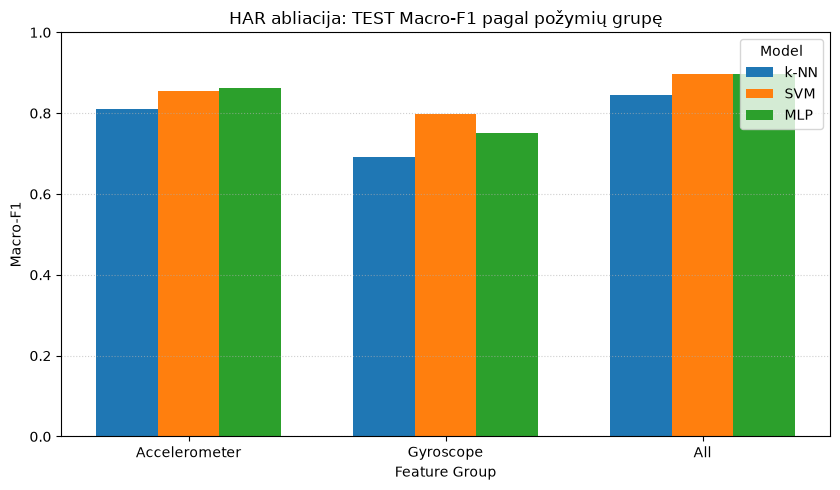

Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\ablation_macro_f1.svg
Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\ablation_macro_f1.png


In [7]:
group_order = ["Accelerometer", "Gyroscope", "All"]
model_order = ["k-NN", "SVM", "MLP"]
pivot = ablation.pivot(index="Feature Group", columns="Model", values="Macro-F1")
pivot = pivot.loc[group_order, model_order]

fig, ax = plt.subplots(figsize=(8.5, 5.0))
x = np.arange(len(group_order))
width = 0.24
for i, model in enumerate(model_order):
    ax.bar(x + (i - 1) * width, pivot[model].to_numpy(), width=width, label=model)

ax.set_xticks(x)
ax.set_xticklabels(group_order)
ax.set_xlabel("Feature Group")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.0, 1.0)
ax.set_title("HAR abliacija: TEST Macro-F1 pagal požymių grupę")
ax.legend(title="Model")
ax.grid(axis="y", linestyle=":", alpha=0.6)
fig.tight_layout()

svg_path = results_dir / "ablation_macro_f1.svg"
png_path = results_dir / "ablation_macro_f1.png"
fig.savefig(svg_path, format="svg")
fig.savefig(png_path, format="png", dpi=200)
plt.show()
print(f"Išsaugota: {svg_path}")
print(f"Išsaugota: {png_path}")

## Interpretacija

Interpretacija remiasi tik šio etapo TEST lentele (9 eksperimentai). Priežasčių, kurių eksperimentas neįrodo, netvirtiname.

**Ar accelerometer-only pakako geram HAR rezultatui.** Šiame eksperimente vien akcelerometro požymių Macro-F1 buvo 0.810 (k-NN), 0.856 (SVM) ir 0.862 (MLP). Tai gerokai aukščiau už 2 etapo Majority Class (~0.053) ir vis dar aukštas lygis, bet visiems trims modeliams žemesnis nei All features. Taigi accelerometer-only davė stiprų, bet ne geriausią rezultatą.

**Kaip pasirodė gyroscope-only.** Giroskopo grupė visiems modeliams buvo silpnesnė už akcelerometrą ir už visus požymius: Macro-F1 0.690 (k-NN), 0.798 (SVM), 0.751 (MLP). Šiame eksperimente gyroscope-only neprilygo accelerometer-only.

**Ar All features pagerino rezultatą.** Taip: visų trijų modelių All Macro-F1 buvo didžiausias (k-NN 0.844, SVM 0.897, MLP 0.897). Delta vs All accelerometer-only yra apie −0.035 … −0.041, gyroscope-only apie −0.099 … −0.154.

**Kuriam modeliui grupės pašalinimas turėjo didžiausią poveikį.** Didžiausias Macro-F1 nuosmukis, palyginti su All, buvo k-NN gyroscope-only (Δ = −0.154). MLP gyroscope-only taip pat smarkiai krito (Δ = −0.146). SVM gyroscope-only kritimas buvo mažesnis (Δ = −0.099). Accelerometer-only poveikis visiems trims modeliams panašus ir mažesnis nei gyroscope-only.

**Hipotezė (neįrodyta).** Galimas paaiškinimas, kad akcelerometro požymių šiame UCI HAR rinkinyje daugiau (348 vs 211) ir jie geriau skiria stovėjimo / ėjimo tipus, bet šis eksperimentas to atskirai nepatikrina — matome tik metrikų skirtumus pagal požymių grupes.

In [8]:
print("Santrauka pagal modelį (Macro-F1):")
for model in model_order:
    sub = ablation[ablation["Model"] == model].set_index("Feature Group")
    print(
        f"  {model}: Acc={sub.loc['Accelerometer', 'Macro-F1']:.6f}, "
        f"Gyro={sub.loc['Gyroscope', 'Macro-F1']:.6f}, "
        f"All={sub.loc['All', 'Macro-F1']:.6f}; "
        f"dAcc={sub.loc['Accelerometer', 'Delta Macro-F1 vs All']:+.6f}, "
        f"dGyro={sub.loc['Gyroscope', 'Delta Macro-F1 vs All']:+.6f}"
    )

Santrauka pagal modelį (Macro-F1):
  k-NN: Acc=0.809685, Gyro=0.690462, All=0.844324; dAcc=-0.034639, dGyro=-0.153862
  SVM: Acc=0.855685, Gyro=0.797924, All=0.897130; dAcc=-0.041445, dGyro=-0.099206
  MLP: Acc=0.861582, Gyro=0.750806, All=0.896616; dAcc=-0.035033, dGyro=-0.145809


## Rezultatų išsaugojimas

`subject_disjoint_split.npz`, `baseline_results.csv` ir `intelligent_models_results.csv` neperrašomi.

In [9]:
out_csv = results_dir / "ablation_results.csv"
ablation.to_csv(out_csv, index=False)
print(f"Išsaugota: {out_csv}")
print("subject_disjoint_split.npz nekeistas.")
print("baseline_results.csv neperrašytas.")
print("intelligent_models_results.csv neperrašytas.")
if caught_warnings:
    print("Užfiksuoti warning:")
    print(pd.DataFrame(caught_warnings).drop_duplicates().to_string(index=False))
else:
    print("Warning šiame paleidime nebuvo užfiksuota.")
print("4 etapas baigtas.")

Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\ablation_results.csv
subject_disjoint_split.npz nekeistas.
baseline_results.csv neperrašytas.
intelligent_models_results.csv neperrašytas.
Warning šiame paleidime nebuvo užfiksuota.
4 etapas baigtas.
